# Hypertension et obésité au Bénin : analyse par département

**Source :** Enquête STEPS 2015, Ministère de la Santé du Bénin (rapport publié en 2016).

**Objectif :** identifier les départements les plus touchés par l'hypertension, afin d'aider les décideurs à mieux cibler le dépistage et la prévention.

## 1. Les départements les plus touchés par l'hypertension

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
donnees = pd.read_csv("/content/tension_departements_2015.csv")
donnees

,departement,taux_2008,ic_bas_2008,ic_haut_2008,taux_2015,ic_bas_2015,ic_haut_2015
0,Oueme,38.82,35.2,42.4,16.2,12.2,20.1
1,Plateau,32.12,27.9,36.4,31.8,24.4,39.2
2,Atlantique,24.07,21.3,26.8,30.5,25.8,35.2
3,Littoral,25.64,22.1,29.2,32.3,22.8,41.7
4,Mono,35.76,30.7,40.8,22.6,17.2,27.9
5,Couffo,29.62,25.9,33.4,19.8,5.1,34.6
6,Zou,23.00,19.9,26.1,15.9,5.8,26.0
7,Collines,28.67,25.0,32.4,29.7,22.9,36.4
8,Borgou,23.44,20.3,26.6,34.4,26.3,42.5
9,Alibori,24.24,20.3,28.1,31.6,24.6,38.5


In [ ]:
donnees.sort_values("taux_2015", ascending=False)

,departement,taux_2008,ic_bas_2008,ic_haut_2008,taux_2015,ic_bas_2015,ic_haut_2015
8,Borgou,23.44,20.3,26.6,34.4,26.3,42.5
3,Littoral,25.64,22.1,29.2,32.3,22.8,41.7
1,Plateau,32.12,27.9,36.4,31.8,24.4,39.2
9,Alibori,24.24,20.3,28.1,31.6,24.6,38.5
2,Atlantique,24.07,21.3,26.8,30.5,25.8,35.2
7,Collines,28.67,25.0,32.4,29.7,22.9,36.4
11,Donga,25.80,21.2,30.4,29.3,21.6,37.0
10,Atacora,23.17,19.7,26.6,24.0,18.7,29.3
4,Mono,35.76,30.7,40.8,22.6,17.2,27.9
5,Couffo,29.62,25.9,33.4,19.8,5.1,34.6


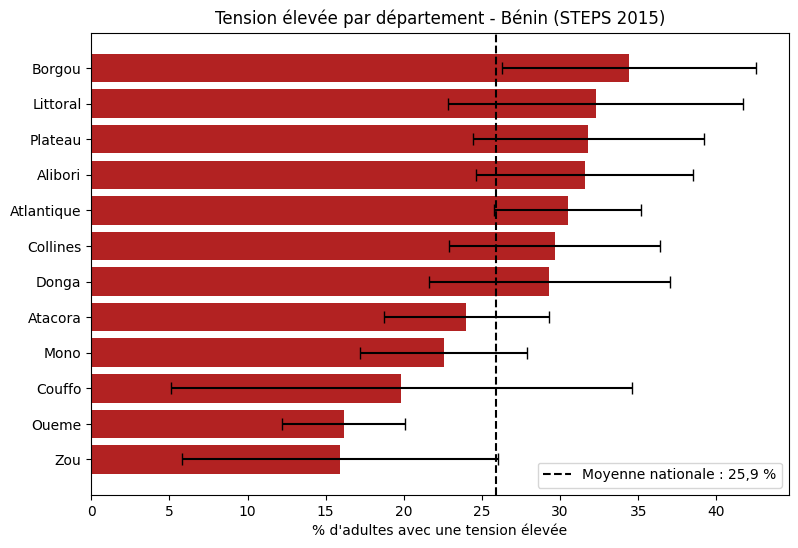

In [ ]:
tri = donnees.sort_values("taux_2015")
erreur_bas = tri["taux_2015"] - tri["ic_bas_2015"]
erreur_haut = tri["ic_haut_2015"] - tri["taux_2015"]

plt.figure(figsize=(9, 6))
plt.barh(tri["departement"], tri["taux_2015"],
         xerr=[erreur_bas, erreur_haut], capsize=4, color="firebrick")
plt.axvline(25.9, color="black", linestyle="--", label="Moyenne nationale : 25,9 %")
plt.xlabel("% d'adultes avec une tension élevée")
plt.title("Tension élevée par département - Bénin (STEPS 2015)")
plt.legend()
plt.show()

Le **Borgou** est le seul département clairement au-dessus de la moyenne nationale (25,9 %). L'**Ouémé** est clairement en dessous. Pour le **Couffo**, la fourchette est très large : le chiffre est peu précis.

## 2. Lien entre obésité et hypertension

In [ ]:
obesite = pd.read_csv("/content/obesite_departements_2015.csv")
fusion = pd.merge(donnees, obesite, on="departement")
fusion[["departement", "taux_2015", "obesite_2015"]]

,departement,taux_2015,obesite_2015
0,Oueme,16.2,5.9
1,Plateau,31.8,6.1
2,Atlantique,30.5,12.7
3,Littoral,32.3,16.5
4,Mono,22.6,4.6
5,Couffo,19.8,4.7
6,Zou,15.9,2.6
7,Collines,29.7,5.4
8,Borgou,34.4,10.7
9,Alibori,31.6,7.6


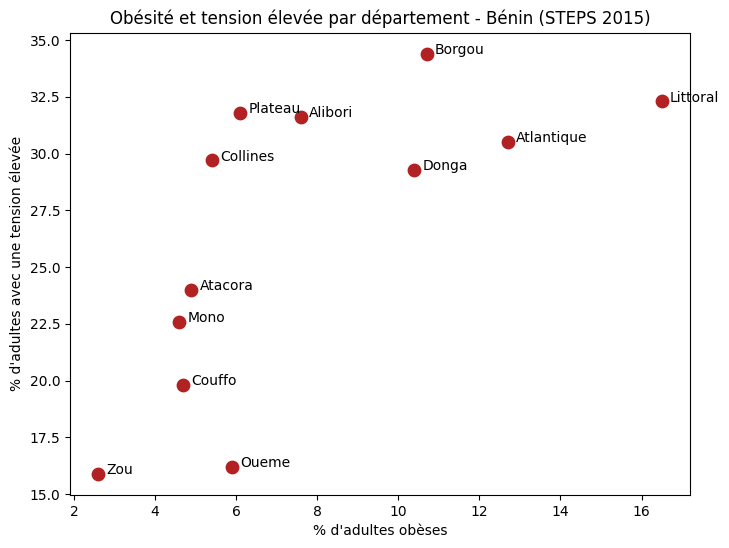

Corrélation : 0.68


In [ ]:
plt.figure(figsize=(8, 6))
plt.scatter(fusion["obesite_2015"], fusion["taux_2015"], color="firebrick", s=80)

for i in range(len(fusion)):
    plt.text(fusion["obesite_2015"][i] + 0.2, fusion["taux_2015"][i], fusion["departement"][i])

plt.xlabel("% d'adultes obèses")
plt.ylabel("% d'adultes avec une tension élevée")
plt.title("Obésité et tension élevée par département - Bénin (STEPS 2015)")
plt.show()

correlation = fusion["obesite_2015"].corr(fusion["taux_2015"])
print("Corrélation :", round(correlation, 2))

Au Bénin en 2015, les départements où l'obésité est la plus fréquente ont tendance à avoir plus d'hypertension (**corrélation de 0,68**). Ce lien ne prouve pas une cause. Certains départements comme le **Plateau**, l'**Alibori** et les **Collines** ont une hypertension élevée malgré une faible obésité, ce qui suggère l'influence d'**autres facteurs** (alcool, sel, tabac, âge…).

## 3. Lien entre alcool et hypertension

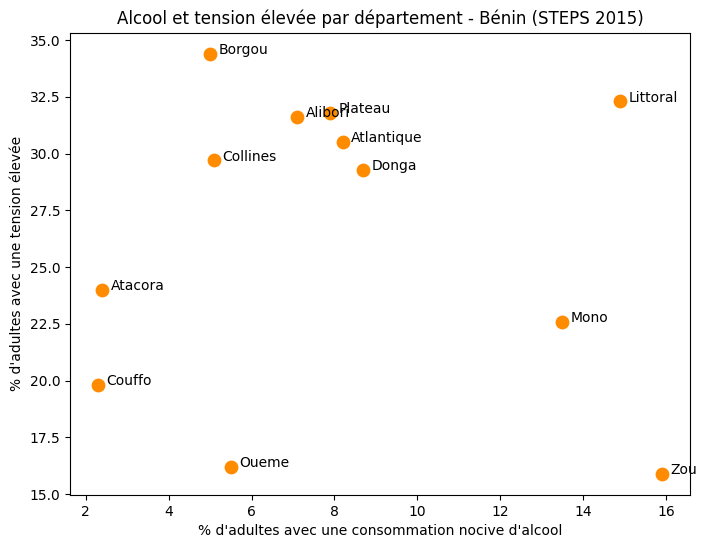

Corrélation alcool / tension : -0.07


In [ ]:
alcool = pd.read_csv("/content/alcool_departements_2015.csv")
fusion2 = pd.merge(fusion, alcool, on="departement")

plt.figure(figsize=(8, 6))
plt.scatter(fusion2["alcool_2015"], fusion2["taux_2015"], color="darkorange", s=80)

for i in range(len(fusion2)):
    plt.text(fusion2["alcool_2015"][i] + 0.2, fusion2["taux_2015"][i], fusion2["departement"][i])

plt.xlabel("% d'adultes avec une consommation nocive d'alcool")
plt.ylabel("% d'adultes avec une tension élevée")
plt.title("Alcool et tension élevée par département - Bénin (STEPS 2015)")
plt.show()

correlation_alcool = fusion2["alcool_2015"].corr(fusion2["taux_2015"])
print("Corrélation alcool / tension :", round(correlation_alcool, 2))

Au niveau des départements, la consommation nocive d'alcool **ne montre pas de lien clair** avec l'hypertension (corrélation proche de 0). L'alcool n'explique donc pas les cas du Plateau, de l'Alibori et des Collines. **Remarque :** la fourchette du Couffo est absente dans le rapport (valeur manquante).

## 4. Lien entre tabac et hypertension

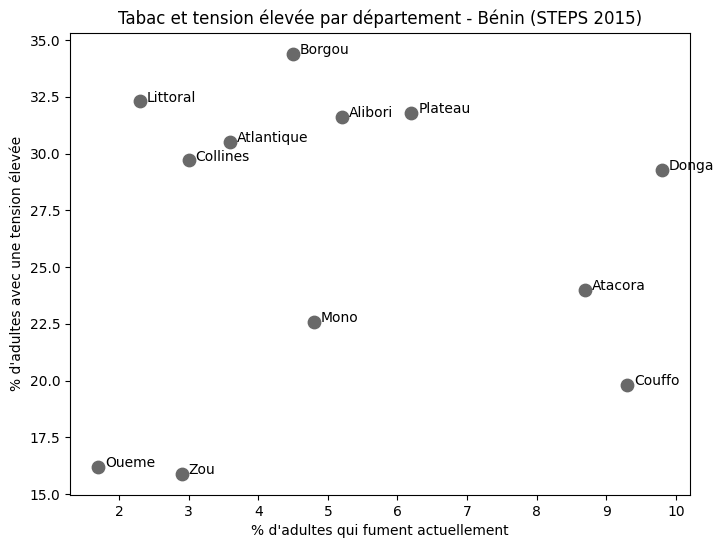

Corrélation tabac / tension : 0.04


In [ ]:
tabac = pd.read_csv("/content/tabac_departements_2015.csv")
fusion3 = pd.merge(fusion2, tabac, on="departement")

plt.figure(figsize=(8, 6))
plt.scatter(fusion3["tabac_2015"], fusion3["taux_2015"], color="dimgray", s=80)

for i in range(len(fusion3)):
    plt.text(fusion3["tabac_2015"][i] + 0.1, fusion3["taux_2015"][i], fusion3["departement"][i])

plt.xlabel("% d'adultes qui fument actuellement")
plt.ylabel("% d'adultes avec une tension élevée")
plt.title("Tabac et tension élevée par département - Bénin (STEPS 2015)")
plt.show()

correlation_tabac = fusion3["tabac_2015"].corr(fusion3["taux_2015"])
print("Corrélation tabac / tension :", round(correlation_tabac, 2))

Au niveau des départements, le tabagisme **ne montre pas de lien clair** avec l'hypertension (corrélation proche de 0). Les départements qui fument le plus (Donga, Atacora, Couffo) n'ont pas l'hypertension la plus élevée. **Attention :** ce résultat concerne les départements, pas les individus ; le tabac reste un facteur de risque reconnu par l'OMS. La fourchette de l'Ouémé est absente dans le rapport (valeur manquante).

## 5. Fruits et légumes, sédentarité et hypertension

**Remarques sur les données :** pour l'Alibori, le chiffre des fruits et légumes (90,2 %) est en dehors de sa fourchette publiée (96,1 – 99,1) : probable erreur dans le rapport. Le tableau de l'activité physique est interprété comme le % d'adultes insuffisamment actifs (sédentarité), comme l'indique le texte du rapport.

In [ ]:
autres = pd.read_csv("/content/fruits_sedentarite_2015.csv")
fusion4 = pd.merge(fusion3, autres, on="departement")

corr_fruits = fusion4["fruits_legumes_2015"].corr(fusion4["taux_2015"])
corr_sedentarite = fusion4["sedentarite_2015"].corr(fusion4["taux_2015"])

print("Corrélation fruits et légumes / tension :", round(corr_fruits, 2))
print("Corrélation sédentarité / tension :", round(corr_sedentarite, 2))

Corrélation fruits et légumes / tension : 0.19
Corrélation sédentarité / tension : -0.27


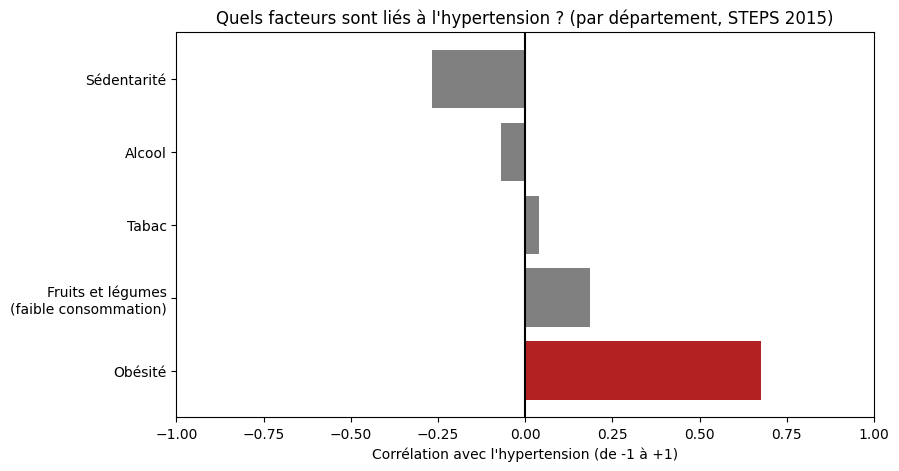

In [ ]:
facteurs = ["Obésité", "Fruits et légumes\n(faible consommation)", "Tabac", "Alcool", "Sédentarité"]
valeurs = [correlation, corr_fruits, correlation_tabac, correlation_alcool, corr_sedentarite]
couleurs = ["firebrick" if v > 0.5 else "gray" for v in valeurs]

plt.figure(figsize=(9, 5))
plt.barh(facteurs, valeurs, color=couleurs)
plt.axvline(0, color="black")
plt.xlim(-1, 1)
plt.xlabel("Corrélation avec l'hypertension (de -1 à +1)")
plt.title("Quels facteurs sont liés à l'hypertension ? (par département, STEPS 2015)")
plt.show()

## 6. Synthèse et recommandations

**Principaux résultats (STEPS 2015) :**
- Environ **1 adulte sur 4** a une tension élevée au Bénin (25,9 %), et **96,2 %** d'entre eux ne sont pas sous traitement.
- Le **Borgou** est le seul département clairement au-dessus de la moyenne nationale.
- Parmi les facteurs étudiés, seule l'**obésité** montre un lien assez fort avec l'hypertension entre départements (corrélation de 0,68). L'alcool, le tabac, les fruits et légumes et la sédentarité ne montrent pas de lien clair à ce niveau.

**Pistes d'action pour les décideurs :**
- Renforcer le **dépistage de l'hypertension**, en priorité dans le **Borgou** et dans les départements où l'obésité est élevée (**Littoral, Atlantique, Donga**).
- Mener des actions de **prévention du surpoids** : alimentation équilibrée, moins de sel, activité physique régulière.
- Encourager chaque adulte à **mesurer régulièrement sa tension**, puisque la grande majorité des malades ne sont pas soignés.

**Limites de l'analyse :**
- Les données datent de **2015** ; une enquête STEPS plus récente (2023) existe, mais son rapport détaillé n'est pas encore accessible publiquement.
- L'analyse porte sur **12 départements** seulement : les

## 7. Le diabète par département

**Source :** Tableau 105, page 100 (glycémie à jeun ≥ 110 mg/dl ou prise de médicaments). Les fourchettes du tableau de la page 128 n'ont pas été utilisées, car elles sont incohérentes avec les pourcentages.

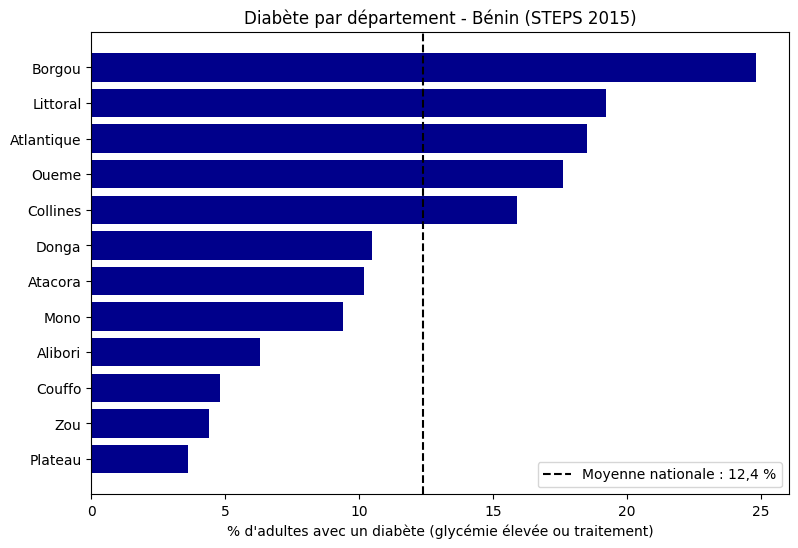

Corrélation diabète / tension : 0.38
Corrélation diabète / obésité : 0.64


In [ ]:
diabete = pd.read_csv("/content/diabete_departements_2015.csv")
fusion5 = pd.merge(fusion4, diabete, on="departement")

tri_d = fusion5.sort_values("diabete_2015")
plt.figure(figsize=(9, 6))
plt.barh(tri_d["departement"], tri_d["diabete_2015"], color="darkblue")
plt.axvline(12.4, color="black", linestyle="--", label="Moyenne nationale : 12,4 %")
plt.xlabel("% d'adultes avec un diabète (glycémie élevée ou traitement)")
plt.title("Diabète par département - Bénin (STEPS 2015)")
plt.legend()
plt.show()

corr_diab_tension = fusion5["diabete_2015"].corr(fusion5["taux_2015"])
corr_diab_obesite = fusion5["diabete_2015"].corr(fusion5["obesite_2015"])
print("Corrélation diabète / tension :", round(corr_diab_tension, 2))
print("Corrélation diabète / obésité :", round(corr_diab_obesite, 2))

Le **Borgou** est le département le plus touché par le diabète (24,8 %), comme pour l'hypertension. Le diabète est **modérément lié** à l'hypertension (corrélation de 0,38) et **assez fortement lié à l'obésité** (0,64). L'obésité apparaît donc comme un **facteur commun aux deux maladies** au niveau des départements, ce qui fait de la **prévention du surpoids** une priorité.

## 8. Synthèse et recommandations

**Principaux résultats (STEPS 2015) :**
- Environ **1 adulte sur 4** a une tension élevée au Bénin (25,9 %), et **96,2 %** d'entre eux ne sont pas sous traitement.
- Environ **1 adulte sur 8** a un diabète (12,4 %).
- Le **Borgou** est le département le plus touché **à la fois** par l'hypertension (34,4 %) et par le diabète (24,8 %).
- Parmi les facteurs étudiés, seule l'**obésité** est liée aux deux maladies entre départements : corrélation de 0,68 avec l'hypertension et de 0,64 avec le diabète. L'alcool, le tabac, les fruits et légumes et la sédentarité ne montrent pas de lien clair à ce niveau.

**Pistes d'action pour les décideurs :**
- Faire du **Borgou** une **zone prioritaire** pour le dépistage de l'hypertension et du diabète.
- Renforcer le dépistage dans les départements où l'obésité, l'hypertension ou le diabète sont élevés (**Littoral, Atlantique, Donga**).
- Mener des actions de **prévention du surpoids** : alimentation équilibrée, moins de sel et de sucre, activité physique régulière.
- Encourager chaque adulte à **mesurer régulièrement sa tension et sa glycémie**, puisque la grande majorité des malades ne sont pas soignés.

**Limites de l'analyse :**
- Les données datent de **2015** ; une enquête STEPS plus récente (2023) existe, mais son rapport détaillé n'est pas encore accessible publiquement.
- L'analyse porte sur **12 départements** : les corrélations montrent des tendances, **pas des causes**, et ne s'appliquent pas directement aux individus.
- Le rapport source contient des **valeurs manquantes** et des **incohérences** (fourchettes de l'hyperglycémie page 128, fruits et légumes pour l'Alibori), signalées dans l'analyse.

## 9. Export des données pour le tableau de bord

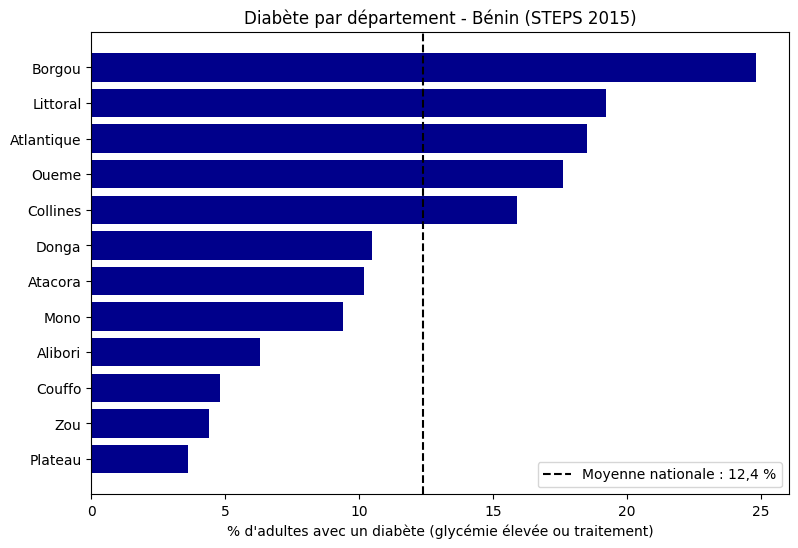

Corrélation diabète / tension : 0.38
Corrélation diabète / obésité : 0.64


In [ ]:
diabete = pd.read_csv("/content/diabete_departements_2015.csv")
fusion5 = pd.merge(fusion4, diabete, on="departement")

tri_d = fusion5.sort_values("diabete_2015")
plt.figure(figsize=(9, 6))
plt.barh(tri_d["departement"], tri_d["diabete_2015"], color="darkblue")
plt.axvline(12.4, color="black", linestyle="--", label="Moyenne nationale : 12,4 %")
plt.xlabel("% d'adultes avec un diabète (glycémie élevée ou traitement)")
plt.title("Diabète par département - Bénin (STEPS 2015)")
plt.legend()
plt.show()

corr_diab_tension = fusion5["diabete_2015"].corr(fusion5["taux_2015"])
corr_diab_obesite = fusion5["diabete_2015"].corr(fusion5["obesite_2015"])
print("Corrélation diabète / tension :", round(corr_diab_tension, 2))
print("Corrélation diabète / obésité :", round(corr_diab_obesite, 2))